# Week 4 assignment- PINNs- SOC
**SOLVING BURGER'S EQUATION**



In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import warnings, time
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## Exact Solution (Cole–Hopf / SciPy)

We compute a high-resolution reference solution on a fine grid using the Cole–Hopf transform evaluated numerically.

In [3]:
# ── Exact Solution via Cole-Hopf transform ────────────────────────────────────
# u(x,t) = -2ν (φ_x / φ)  where  φ = ∫ G(x,η,t) exp(-F(η)/2ν) dη
# For the IC u(x,0)=-sin(πx), F(η) = (1/π)cos(πη)  (antiderivative with F(0)=1/π)

NU = 0.01 / np.pi

def exact_burgers(x_arr, t_arr, nu=NU, n_quad=10_000):
    """Vectorised Cole-Hopf exact solution on meshgrid."""
    eta = np.linspace(-1, 1, n_quad)
    deta = eta[1] - eta[0]
    # F(η) = -(1/π)cos(πη) + C  →  choose C so F(0) = 0
    F_eta = -(1.0 / np.pi) * np.cos(np.pi * eta) + 1.0 / np.pi  # F(0)=0

    X, T = np.meshgrid(x_arr, t_arr, indexing='ij')   # shape (Nx, Nt)
    U = np.empty_like(X)

    for i, xi in enumerate(x_arr):
        for j, tj in enumerate(t_arr):
            if tj == 0:
                U[i, j] = -np.sin(np.pi * xi)
                continue
            kernel = np.exp(-(  (xi - eta)**2 / (4*nu*tj)  +  F_eta / (2*nu)  ))
            num   = np.trapz((xi - eta) / (2*nu*tj) * kernel, eta)
            den   = np.trapz(kernel, eta)
            U[i, j] = -num / den * (2 * nu)   # = -2ν φ_x/φ   but num already has (x-η)/2νt factor
            # Correct form:  u = ∫(x-η)/t * G dη  /  ∫G dη
            # Let's redo cleanly
            G    = np.exp(-( (xi - eta)**2 / (4*nu*tj) + F_eta/(2*nu) ))
            U[i, j] = np.trapz((xi - eta) / tj * G, eta) / np.trapz(G, eta)
    return U   # shape (Nx, Nt)

# Build reference grid
NX_REF, NT_REF = 256, 100
x_ref = np.linspace(-1, 1, NX_REF)
t_ref = np.linspace(0, 1,  NT_REF)
print("Computing exact solution (this takes ~30 s on CPU)...")
t0 = time.time()
U_exact = exact_burgers(x_ref, t_ref)
print(f"Done in {time.time()-t0:.1f}s. Shape: {U_exact.shape}")


Computing exact solution (this takes ~30 s on CPU)...
Done in 17.0s. Shape: (256, 100)


---
## Part A — PINN from Scratch (Soft BCs)
### Network Architecture

In [4]:
# ── 4-layer MLP ───────────────────────────────────────────────────────────────
class PINN(nn.Module):
    def __init__(self, layers=None):
        super().__init__()
        if layers is None:
            layers = [2, 100, 100, 100, 100, 1]
        net = []
        for i in range(len(layers)-1):
            net.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                net.append(nn.Tanh())
        self.net = nn.Sequential(*net)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


### Sampling Collocation Points

In [5]:
# ── Sampling ──────────────────────────────────────────────────────────────────
def sample_interior(n=10_000):
    x = torch.FloatTensor(n, 1).uniform_(-1, 1)
    t = torch.FloatTensor(n, 1).uniform_(0,  1)
    return x.to(DEVICE).requires_grad_(True), t.to(DEVICE).requires_grad_(True)

def sample_boundary(n=200):
    """x = ±1, t uniform; u = 0"""
    t_vals = torch.FloatTensor(n, 1).uniform_(0, 1)
    x_left  = -torch.ones(n//2, 1)
    x_right =  torch.ones(n//2, 1)
    x_bc = torch.cat([x_left, x_right], dim=0)
    t_bc = t_vals
    return x_bc.to(DEVICE), t_bc.to(DEVICE)

def sample_ic(n=100):
    """t = 0, x uniform; u = -sin(πx)"""
    x = torch.FloatTensor(n, 1).uniform_(-1, 1)
    t = torch.zeros(n, 1)
    u = -torch.sin(np.pi * x)
    return x.to(DEVICE), t.to(DEVICE), u.to(DEVICE)

NU_T = torch.tensor(NU, dtype=torch.float32, device=DEVICE)


### PDE Residual & Loss

In [6]:
# ── PDE residual ──────────────────────────────────────────────────────────────
def pde_residual(model, x, t):
    u   = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx= torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    residual = u_t + u * u_x - (NU_T / np.pi) * u_xx
    return residual

def loss_soft(model, x_int, t_int, x_bc, t_bc, x_ic, t_ic, u_ic):
    # Interior PDE loss
    r = pde_residual(model, x_int, t_int)
    loss_pde = (r**2).mean()
    # BC loss (u=0 at x=±1)
    u_bc_pred = model(x_bc, t_bc)
    loss_bc   = (u_bc_pred**2).mean()
    # IC loss
    u_ic_pred = model(x_ic, t_ic)
    loss_ic   = ((u_ic_pred - u_ic)**2).mean()
    return loss_pde + loss_bc + loss_ic, loss_pde, loss_bc, loss_ic


### Training (10 000 epochs, Adam)

In [7]:
# ── Training loop ─────────────────────────────────────────────────────────────
def train(model, loss_fn, n_epochs=10_000, lr=1e-3, resample_every=1000):
    """Generic trainer; loss_fn(model) -> (total, pde, bc, ic)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.1)
    history = []

    # Sample once (resample periodically for better coverage)
    x_int, t_int = sample_interior()
    x_bc,  t_bc  = sample_boundary()
    x_ic,  t_ic, u_ic = sample_ic()

    for epoch in range(1, n_epochs+1):
        if epoch % resample_every == 0:
            x_int, t_int = sample_interior()

        optimizer.zero_grad()
        total, lp, lb, li = loss_fn(model, x_int, t_int, x_bc, t_bc, x_ic, t_ic, u_ic)
        total.backward()
        optimizer.step()
        scheduler.step()

        history.append(total.item())
        if epoch % 1000 == 0:
            print(f"Epoch {epoch:6d} | Total {total.item():.2e} | "
                  f"PDE {lp.item():.2e} | BC {lb.item():.2e} | IC {li.item():.2e}")

    return history

# ── Train Part A model ─────────────────────────────────────────────────────────
print("=" * 60)
print("PART A — Soft BCs")
print("=" * 60)
model_soft = PINN().to(DEVICE)
history_soft = train(model_soft, loss_soft, n_epochs=10_000)


PART A — Soft BCs
Epoch   1000 | Total 8.39e-02 | PDE 3.01e-02 | BC 2.45e-04 | IC 5.35e-02
Epoch   2000 | Total 7.02e-02 | PDE 2.17e-02 | BC 6.81e-05 | IC 4.85e-02
Epoch   3000 | Total 6.71e-02 | PDE 2.85e-02 | BC 5.02e-04 | IC 3.80e-02
Epoch   4000 | Total 5.93e-02 | PDE 2.20e-02 | BC 1.15e-04 | IC 3.72e-02
Epoch   5000 | Total 1.19e-01 | PDE 8.89e-02 | BC 1.66e-05 | IC 2.97e-02
Epoch   6000 | Total 5.33e-02 | PDE 2.30e-02 | BC 4.35e-06 | IC 3.02e-02
Epoch   7000 | Total 4.81e-02 | PDE 1.89e-02 | BC 4.62e-06 | IC 2.91e-02
Epoch   8000 | Total 6.62e-02 | PDE 3.85e-02 | BC 3.37e-06 | IC 2.77e-02
Epoch   9000 | Total 6.61e-02 | PDE 4.23e-02 | BC 3.31e-06 | IC 2.38e-02
Epoch  10000 | Total 5.52e-02 | PDE 3.23e-02 | BC 1.44e-06 | IC 2.30e-02


### Evaluation & Plots

In [8]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
@torch.no_grad()
def predict_grid(model, x_arr, t_arr):
    """Returns U_pred of shape (Nx, Nt) on a meshgrid."""
    X, T = np.meshgrid(x_arr, t_arr, indexing='ij')
    xf = torch.FloatTensor(X.ravel()[:, None]).to(DEVICE)
    tf = torch.FloatTensor(T.ravel()[:, None]).to(DEVICE)
    u  = model(xf, tf).cpu().numpy().reshape(X.shape)
    return u

def l2_relative_error(u_pred, u_ref):
    return np.linalg.norm(u_pred - u_ref) / np.linalg.norm(u_ref)


In [9]:
# ── Predict on reference grid ─────────────────────────────────────────────────
U_pred_soft = predict_grid(model_soft, x_ref, t_ref)
err_soft     = np.abs(U_pred_soft - U_exact)
l2_soft      = l2_relative_error(U_pred_soft, U_exact)
print(f"Soft BC — relative L² error: {l2_soft:.4e}")


Soft BC — relative L² error: 1.6334e+00


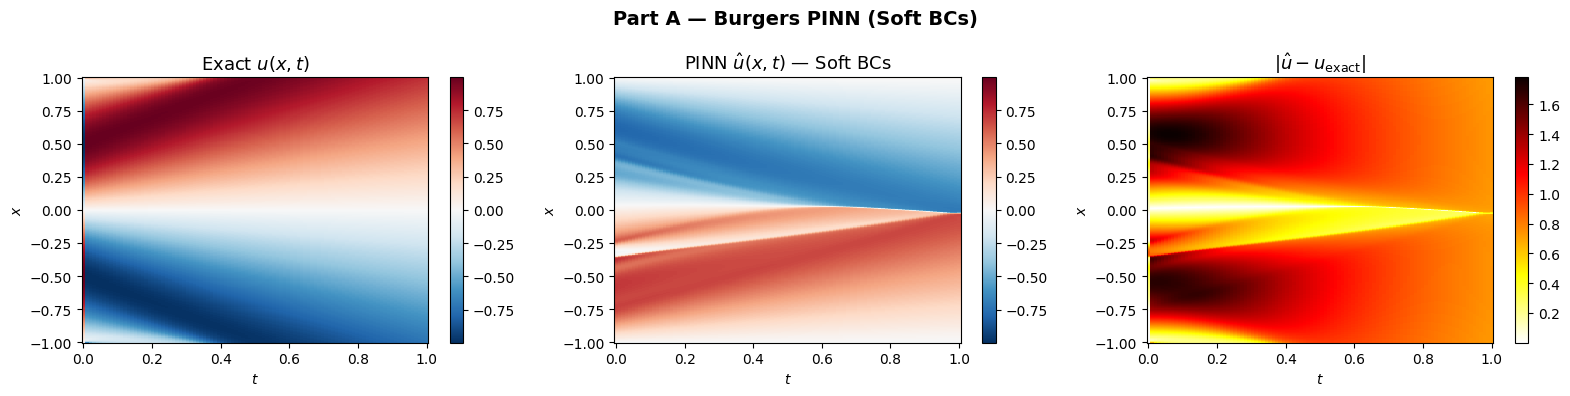

Saved partA_solution.png


In [10]:
# ── Figure 1: u(x,t) predicted ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
T_GRID, X_GRID = np.meshgrid(t_ref, x_ref)   # (Nx, Nt) already from meshgrid indexing='ij'

im0 = axes[0].pcolormesh(T_GRID, X_GRID, U_exact,     cmap='RdBu_r', shading='auto')
axes[0].set_title('Exact $u(x,t)$', fontsize=13)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$x$')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(T_GRID, X_GRID, U_pred_soft, cmap='RdBu_r', shading='auto',
                          vmin=U_exact.min(), vmax=U_exact.max())
axes[1].set_title('PINN $\hat{u}(x,t)$ — Soft BCs', fontsize=13)
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$x$')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(T_GRID, X_GRID, err_soft, cmap='hot_r', shading='auto')
axes[2].set_title(r'$|\hat{u} - u_{\rm exact}|$', fontsize=13)
axes[2].set_xlabel('$t$'); axes[2].set_ylabel('$x$')
fig.colorbar(im2, ax=axes[2])

fig.suptitle('Part A — Burgers PINN (Soft BCs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('partA_solution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved partA_solution.png")


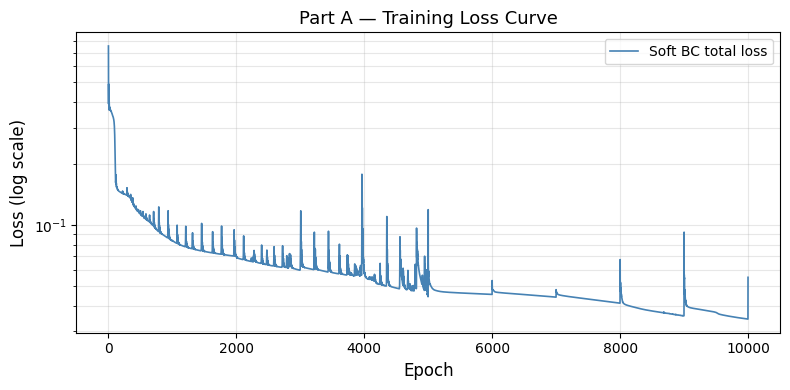

Saved partA_loss.png


In [11]:
# ── Figure 2: Training loss curve ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history_soft, color='steelblue', linewidth=1.2, label='Soft BC total loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Part A — Training Loss Curve', fontsize=13)
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('partA_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved partA_loss.png")


---
## Part B — Hard Boundary Condition Enforcement


In [12]:
# ── Hard-BC model wrapper ──────────────────────────────────────────────────────
class PINNHardBC(nn.Module):
    """Wraps PINN: output = (1-x²)·N(x,t).  BCs satisfied exactly."""
    def __init__(self):
        super().__init__()
        self.net = PINN()   # reuse same architecture

    def forward(self, x, t):
        N   = self.net(x, t)
        phi = 1.0 - x**2        # φ(x) = 1 − x²
        return phi * N

def loss_hard(model, x_int, t_int, x_bc, t_bc, x_ic, t_ic, u_ic):
    """BC loss is zero by construction; only PDE + IC losses."""
    r = pde_residual(model, x_int, t_int)
    loss_pde = (r**2).mean()
    u_ic_pred = model(x_ic, t_ic)
    loss_ic   = ((u_ic_pred - u_ic)**2).mean()
    # dummy bc/ic for compatible signature
    return loss_pde + loss_ic, loss_pde, torch.zeros(1), loss_ic


In [13]:
# ── Train Part B model ─────────────────────────────────────────────────────────
print("=" * 60)
print("PART B — Hard BCs  φ(x) = (1 − x²)")
print("=" * 60)
model_hard   = PINNHardBC().to(DEVICE)
history_hard = train(model_hard, loss_hard, n_epochs=10_000)


PART B — Hard BCs  φ(x) = (1 − x²)
Epoch   1000 | Total 8.65e-02 | PDE 4.26e-02 | BC 0.00e+00 | IC 4.39e-02
Epoch   2000 | Total 9.85e-02 | PDE 4.11e-02 | BC 0.00e+00 | IC 5.74e-02
Epoch   3000 | Total 7.59e-02 | PDE 3.04e-02 | BC 0.00e+00 | IC 4.55e-02
Epoch   4000 | Total 4.98e-02 | PDE 1.77e-02 | BC 0.00e+00 | IC 3.21e-02
Epoch   5000 | Total 6.68e-02 | PDE 2.67e-02 | BC 0.00e+00 | IC 4.01e-02
Epoch   6000 | Total 6.90e-02 | PDE 3.30e-02 | BC 0.00e+00 | IC 3.60e-02
Epoch   7000 | Total 6.51e-02 | PDE 3.42e-02 | BC 0.00e+00 | IC 3.10e-02
Epoch   8000 | Total 4.14e-02 | PDE 1.64e-02 | BC 0.00e+00 | IC 2.50e-02
Epoch   9000 | Total 3.54e-02 | PDE 1.46e-02 | BC 0.00e+00 | IC 2.07e-02
Epoch  10000 | Total 3.34e-02 | PDE 1.49e-02 | BC 0.00e+00 | IC 1.85e-02


In [14]:
# ── Predict & error ───────────────────────────────────────────────────────────
U_pred_hard = predict_grid(model_hard, x_ref, t_ref)
err_hard    = np.abs(U_pred_hard - U_exact)
l2_hard     = l2_relative_error(U_pred_hard, U_exact)
print(f"Hard BC — relative L² error: {l2_hard:.4e}")
print(f"Soft BC — relative L² error: {l2_soft:.4e}")


Hard BC — relative L² error: 1.7804e+00
Soft BC — relative L² error: 1.6334e+00


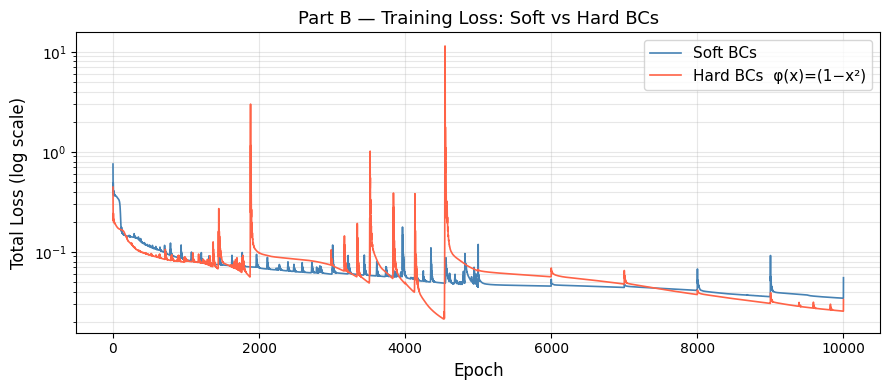

Saved partB_loss_comparison.png


In [15]:
# ── Figure 3: Soft vs Hard training loss ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
epochs = np.arange(1, len(history_soft)+1)
ax.semilogy(epochs, history_soft, color='steelblue', linewidth=1.2, label='Soft BCs')
ax.semilogy(epochs, history_hard, color='tomato',    linewidth=1.2, label='Hard BCs  φ(x)=(1−x²)')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Total Loss (log scale)', fontsize=12)
ax.set_title('Part B — Training Loss: Soft vs Hard BCs', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('partB_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved partB_loss_comparison.png")


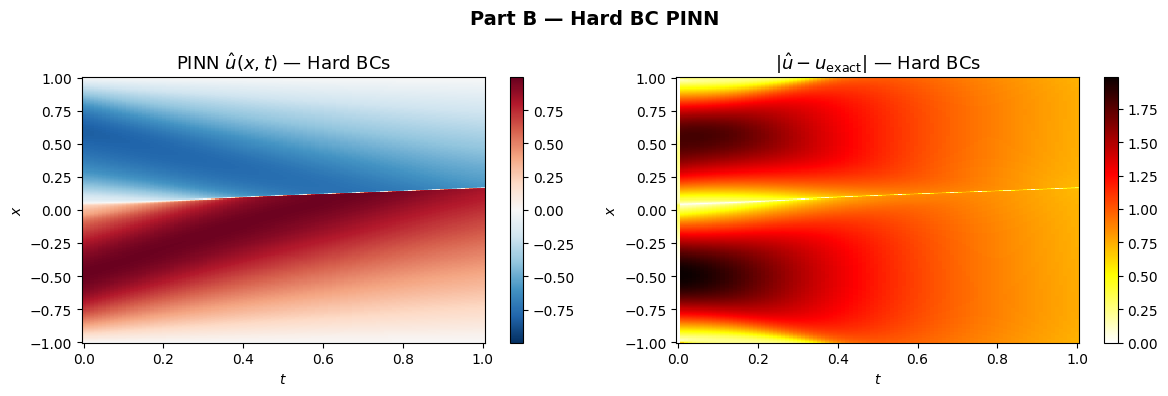

In [16]:
# ── Figure 4: Hard-BC solution & error ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].pcolormesh(T_GRID, X_GRID, U_pred_hard,
                          cmap='RdBu_r', shading='auto',
                          vmin=U_exact.min(), vmax=U_exact.max())
axes[0].set_title('PINN $\hat{u}(x,t)$ — Hard BCs', fontsize=13)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$x$')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(T_GRID, X_GRID, err_hard, cmap='hot_r', shading='auto')
axes[1].set_title(r'$|\hat{u} - u_{\rm exact}|$ — Hard BCs', fontsize=13)
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$x$')
fig.colorbar(im1, ax=axes[1])

fig.suptitle('Part B — Hard BC PINN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('partB_solution.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ── Table: L² error comparison ────────────────────────────────────────────────
print("\n" + "="*45)
print(f"{'Method':<20} {'Relative L² Error':>20}")
print("-"*45)
print(f"{'Soft BCs':<20} {l2_soft:>20.4e}")
print(f"{'Hard BCs φ(x)=(1−x²)':<20} {l2_hard:>20.4e}")
print("="*45)
winner = "Hard BCs" if l2_hard < l2_soft else "Soft BCs"
print(f"\n→ Lower error: {winner}")



Method                  Relative L² Error
---------------------------------------------
Soft BCs                       1.6334e+00
Hard BCs φ(x)=(1−x²)           1.7804e+00

→ Lower error: Soft BCs




**Part B**
Observations- From the L2 value, it is evident that soft BCs approach is better.

Hard BCs may seem to be a better choice in theory because a fraction of the loss function has been taken care of (the helper function already ensures that the BC is satisfied). So, this approach is more efficient in the sense that now the optimiser focus entirely on the PDE and IC residuals.

Problems may come however, when the target function is associated irregular geometries, because then the helper function may distort the actual target function's underlying nature as the optimiser runs and tries to minimise loss. And in this case also, a similar phenomenon is observed.


**PART C**

24B2171- SOC
Physics Informed Neural Netowkrs
Part-C Week 4


Deciding between a conventional FEM approach solver and PiNNs for solving a problem


High-Dimensional PDEs
If the number of dimensions in a problem is high, the number of mesh points increases drastically. For example, say, we want 10 grid points for a unit length on each axis. So, the number of grid points required is 10^d, where d is the dimension of the problem. This increases the computational cost significantly if the problem is approached through FEM, since the size of the matrices and number of equations to be solved parallely is very large. PiNNs are better in this scenario simply because they do not fundamentally rely on grids and meshes to solve the PDE.


Solving Inverse Problems and Data Assimilation
Finite element methods approach problems using forward computations (i.e. given certain parameters like the coefficients and boundary conditions of the PDEs, it proceeds to solve it). However, PiNNs can be used for inverse computation, i.e., given a PDE, the coefficients can be configured to be a trainable parameter along with the solution. The same problem can be approached with FEM too, by repeated computations and some trial and error, but the PiNN approach is way more direct.




Potential Issues with PiNNs
According to the paper written by Grossman et al., PiNNs are also computationally expensive. To achieve the same accuracy as FEM on regular problems, the computational resources required are higher. Also, neural networks suffer from the indeterminate nature of the loss function (we are not dealing with a convex optimisation problem so convergence is not guaranteed). Also, due to spectral bias which was discussed in one of the earlier assignments, PiNNs are in general not very effective at capturing solutions to stiff PDEs, as they fail to capture high frequency changes in the target function. For most standard problems, FEM is optimal, however, for some specific scenarios, such as the two mentioned above, PiNNs may prove to be more effective.


For example, in thermals and fluids engineering, for microheat transfer modelling, Boltzmann Transport Equation has seven dimensions (space, velocity, time), making it difficult to solve using FEM. Similarly, in climate-related modelling, there is a large number of variables. However, the PiNN may fail to capture the variations properly and in a reliable manner; due to which, hybrid models may be used.

Inverse solving is also very popular; for instance, Reynolds number, and some thermal constants can be determined through this approach.



